# 03 — Coordinate Projection
Homography-based projection from camera frame to top-down floor plan.

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, '..')
from src.heatmap import FLOOR_W, FLOOR_H, cx, cy, R, FLOOR_POLYGON, make_floor_canvas, project_points

sns.set_theme(style='whitegrid')

RAW      = Path('../data/raw')
PROCESSED = Path('../data/processed')

## Original Homography (5-pt)

### Reference point selection

Display frame 85 with a coordinate grid overlay. Hover over the ellipse
points to read pixel coordinates, then fill them in the next cell.

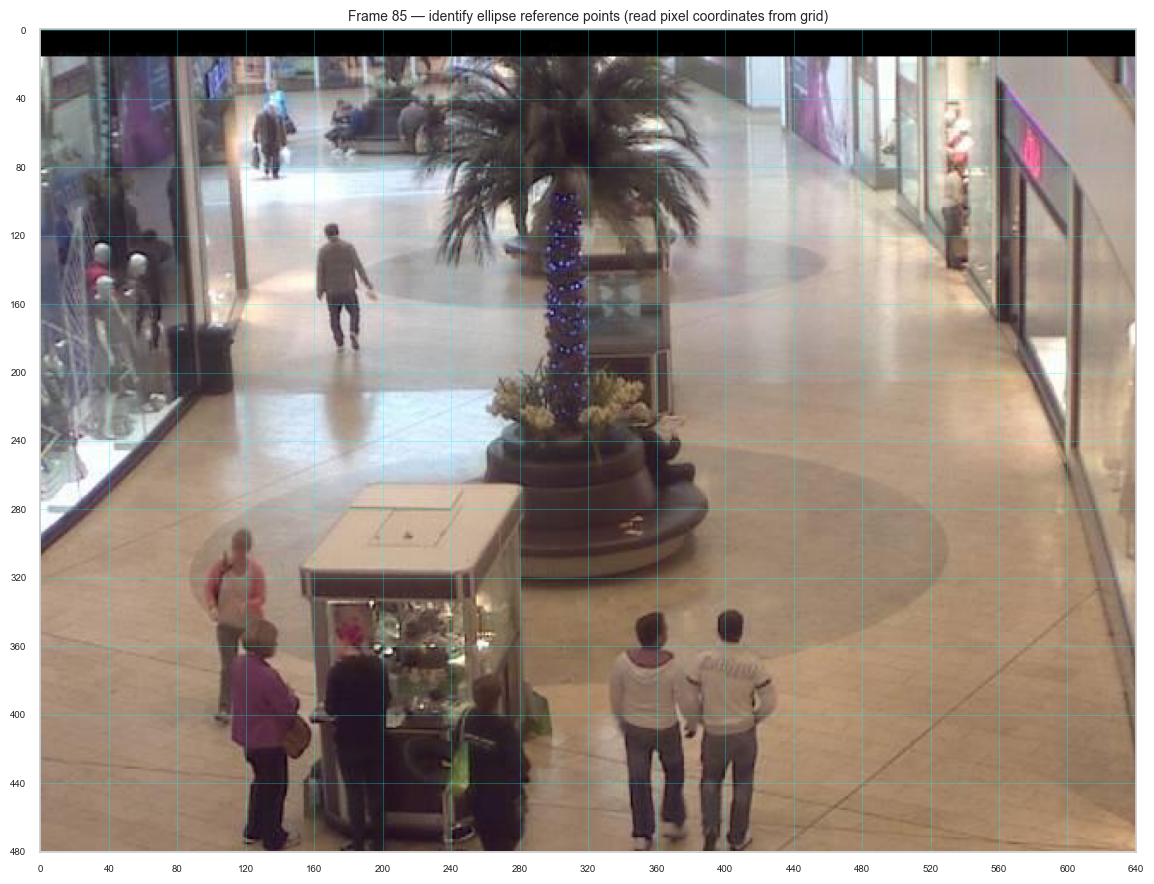

In [2]:
img = mpimg.imread(str(RAW / 'frames/seq_000085.jpg'))

fig, ax = plt.subplots(figsize=(13, 9))
ax.imshow(img)
ax.grid(False)
ax.grid(True, color='cyan', alpha=0.4, linewidth=0.5)
ax.set_xticks(range(0, 641, 40))
ax.set_yticks(range(0, 481, 40))
ax.tick_params(labelsize=7)
ax.set_title('Frame 85 — identify ellipse reference points (read pixel coordinates from grid)', fontsize=10)
plt.tight_layout()
plt.show()

### Define reference points

Fill in the pixel coordinates you read from the frame above.
Pick 4–6 points spread around the ellipse (left, right, near, far, and diagonals).

In the floor plan (top-down view) the ellipse is a true circle.
The `dst_pts` are the corresponding positions on that circle — computed
from a chosen centre and radius on the floor plan canvas.

In [3]:
# ── Camera-frame reference points ────────────────────────────────────────
src_pts = np.float32([
    [206, 378],  # pt1 — bottom of ellipse, nearest to camera
    [432, 248],  # pt2 — top of ellipse, furthest from camera
    [138, 272],  # pt3 — left of ellipse
    [500, 339],  # pt4 — right of ellipse
    [321, 139],  # pt5 — second palm tree base (behind first)
])

# ── Floor plan destination points ────────────────────────────────────────
# Canvas constants (FLOOR_W, FLOOR_H, cx, cy, R) imported from src.heatmap
dst_pts = np.float32([
    [cx,     cy + R],  # pt1 — bottom  (6 o'clock)
    [cx,     cy - R],  # pt2 — top     (12 o'clock)
    [cx - R, cy    ],  # pt3 — left    (9 o'clock)
    [cx + R, cy    ],  # pt4 — right   (3 o'clock)
    [cx,     510   ],  # pt5 — second palm tree (shifted with canvas)
])

print('src_pts:', src_pts)
print('dst_pts:', dst_pts)

src_pts: [[206. 378.]
 [432. 248.]
 [138. 272.]
 [500. 339.]
 [321. 139.]]
dst_pts: [[520. 980.]
 [520. 720.]
 [390. 850.]
 [650. 850.]
 [520. 510.]]


### Compute homography

In [4]:
H, mask = cv2.findHomography(src_pts, dst_pts, method=0)
print('Homography matrix:')
print(H.round(4))
print(f'\nAll {int(mask.sum())}/{len(src_pts)} points used (no outliers)')

Homography matrix:
[[ 4.44419000e+01  3.29247000e+01 -6.71060610e+03]
 [ 3.54837000e+01  8.62396000e+01 -1.07992392e+04]
 [ 5.36000000e-02  4.59000000e-02  1.00000000e+00]]

All 0/5 points used (no outliers)


### Floor plan sketch + reference point validation

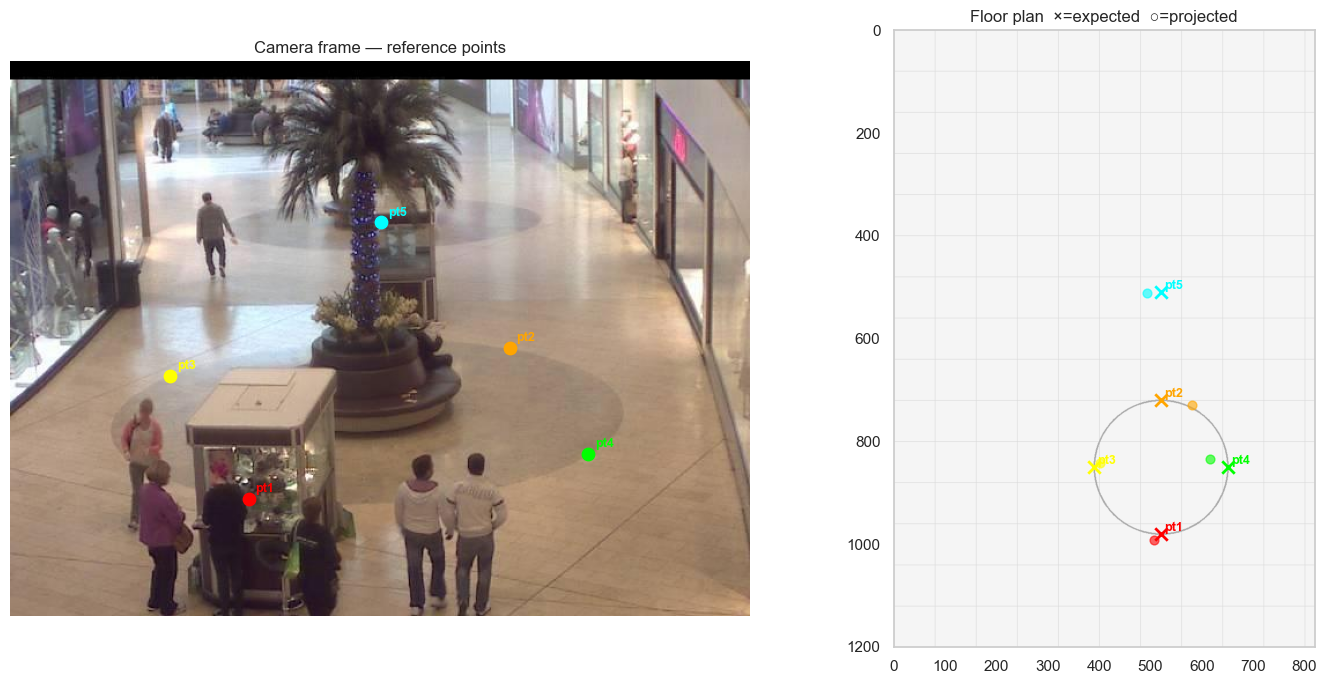

pt1 reprojection error: 17.2 px
pt2 reprojection error: 62.5 px
pt3 reprojection error: 14.4 px
pt4 reprojection error: 37.4 px
pt5 reprojection error: 26.2 px


In [5]:
floor_plan = make_floor_canvas()
proj = project_points(src_pts, H)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: camera frame with reference points
img85 = mpimg.imread(str(RAW / 'frames/seq_000085.jpg'))
axes[0].imshow(img85)
colours = ['red', 'orange', 'yellow', 'lime', 'cyan']
for i, (xy, c) in enumerate(zip(src_pts, colours)):
    axes[0].scatter(*xy, color=c, s=80, zorder=5)
    axes[0].text(xy[0]+6, xy[1]-6, f'pt{i+1}', color=c, fontsize=9, fontweight='bold')
axes[0].set_title('Camera frame — reference points')
axes[0].axis('off')

# Right: floor plan — expected (×) vs projected (o)
axes[1].imshow(floor_plan)
axes[1].grid(False)
for i, (d, p, c) in enumerate(zip(dst_pts, proj, colours)):
    axes[1].scatter(*d, color=c, s=80, marker='x', zorder=6, linewidths=2)
    axes[1].scatter(*p, color=c, s=40, marker='o', zorder=5, alpha=0.6)
    axes[1].text(d[0]+6, d[1]-6, f'pt{i+1}', color=c, fontsize=9, fontweight='bold')
axes[1].set_title('Floor plan  ×=expected  ○=projected')
axes[1].set_xlim(0, FLOOR_W); axes[1].set_ylim(FLOOR_H, 0)

plt.tight_layout()
plt.show()

reprojection_err = np.linalg.norm(proj - dst_pts, axis=1)
for i, e in enumerate(reprojection_err):
    print(f'pt{i+1} reprojection error: {e:.1f} px')

### Project foot positions from a few frames

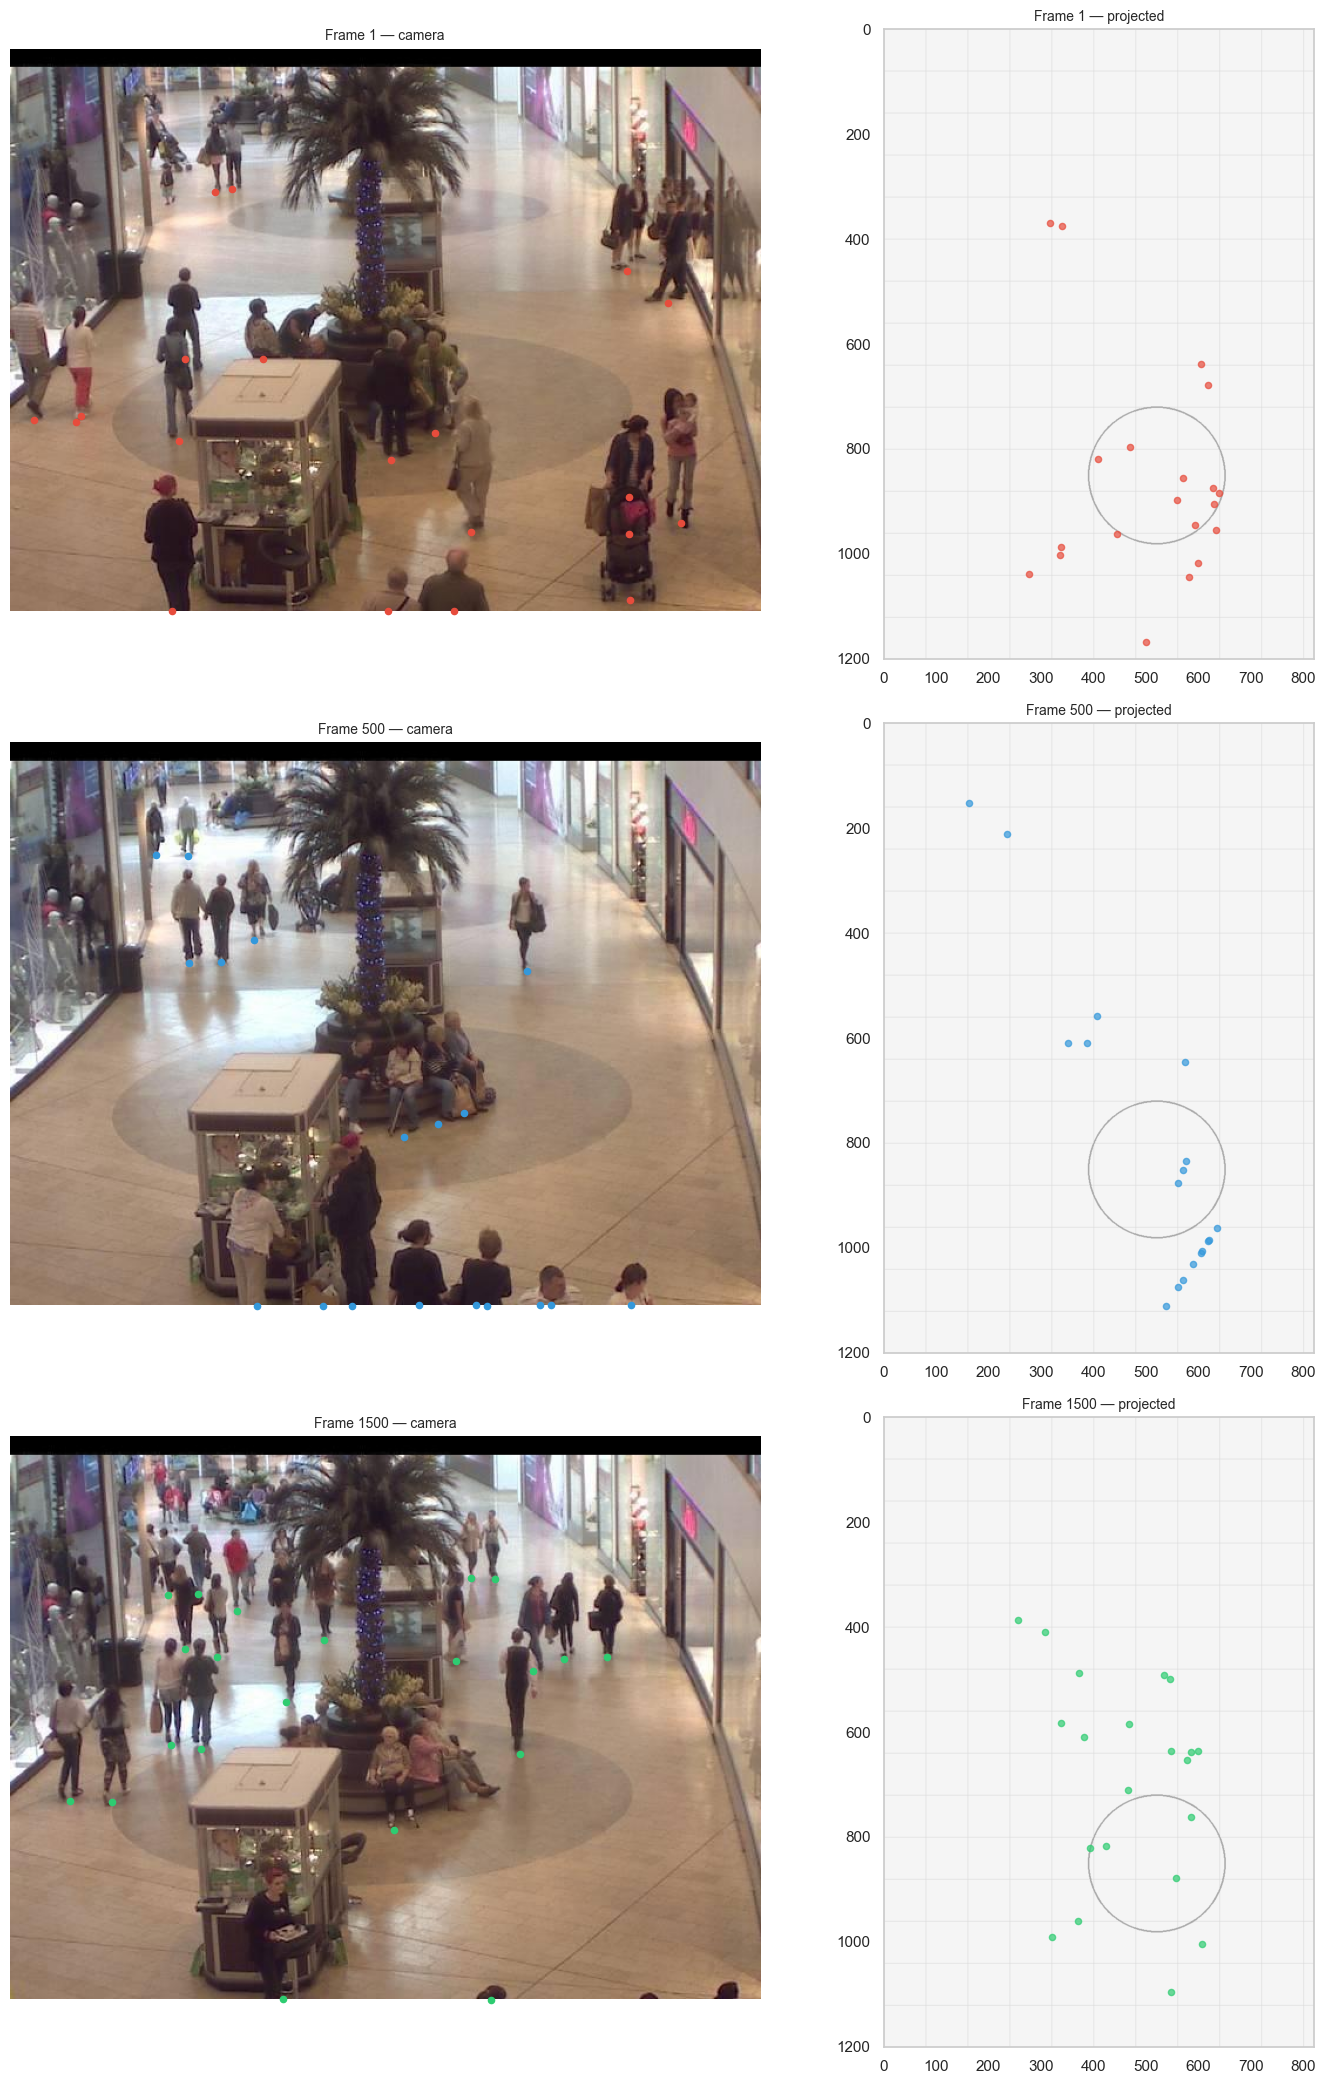

In [6]:
detections = pd.read_csv('../data/interim/detections.csv')

sample_frames = [1, 500, 1500]
colours_f = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(3, 2, figsize=(15, 21))

for (cam_ax, floor_ax), frame_id, col in zip(axes, sample_frames, colours_f):
    rows = detections[detections['frame_id'] == frame_id][['x', 'y']].values
    proj_pts = project_points(rows, H)

    cam_ax.imshow(mpimg.imread(str(RAW / f'frames/seq_{frame_id:06d}.jpg')))
    cam_ax.scatter(rows[:, 0], rows[:, 1], color=col, s=20, zorder=5)
    cam_ax.set_title(f'Frame {frame_id} — camera', fontsize=10)
    cam_ax.axis('off')

    floor_ax.imshow(make_floor_canvas())
    floor_ax.grid(False)
    floor_ax.scatter(proj_pts[:, 0], proj_pts[:, 1], color=col, s=20, zorder=5, alpha=0.7)
    floor_ax.set_xlim(0, FLOOR_W)
    floor_ax.set_ylim(FLOOR_H, 0)
    floor_ax.set_title(f'Frame {frame_id} — projected', fontsize=10)

plt.tight_layout()
plt.show()

### Save homography matrix

In [7]:
PROCESSED = Path('../data/processed')

np.save(PROCESSED / 'homography.npy', H)
print('Saved H to data/processed/homography.npy')
print(f'Canvas: FLOOR_W={FLOOR_W}, FLOOR_H={FLOOR_H}, cx={cx}, cy={cy}, R={R}')

Saved H to data/processed/homography.npy
Canvas: FLOOR_W=820, FLOOR_H=1200, cx=520, cy=850, R=130


## New Homography (10-pt)

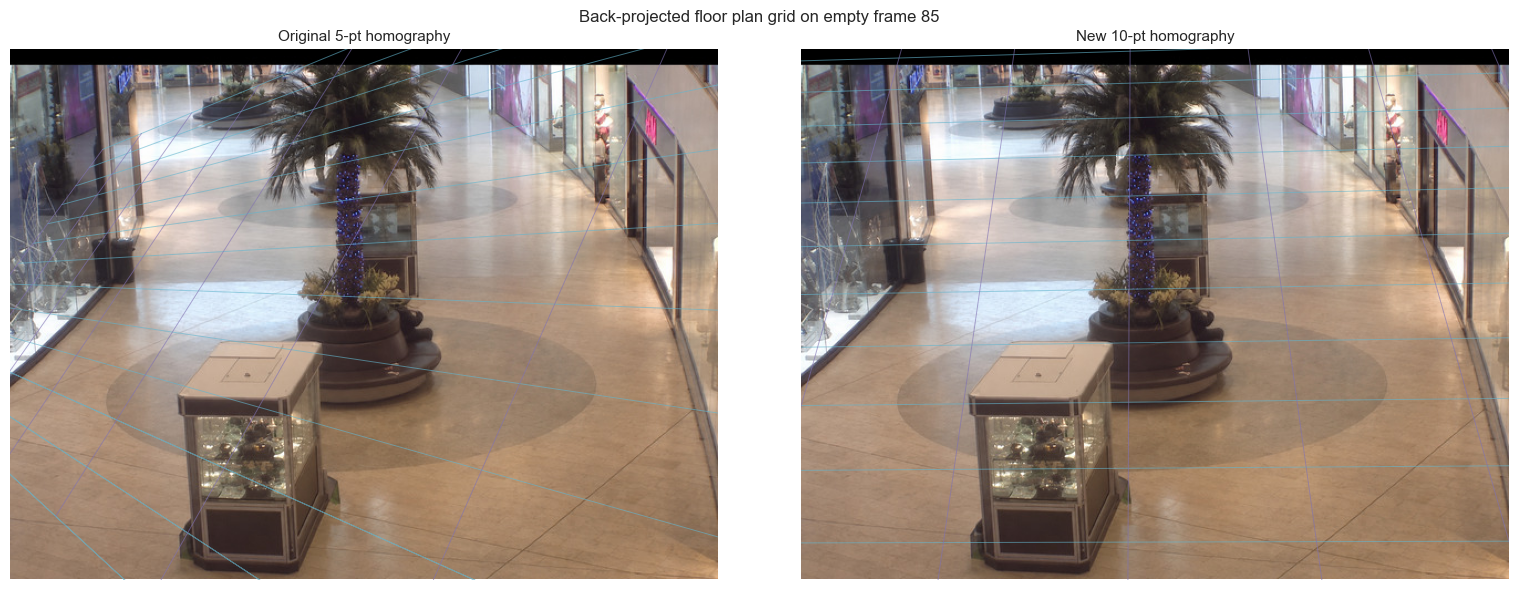

In [8]:
H_new = np.load(PROCESSED / 'homography_10pt.npy')

frame85 = mpimg.imread('../reports/figures/Empty_frame_85.jpg')
xs = np.arange(0, FLOOR_W + 1, 100)
ys = np.arange(0, FLOOR_H + 1, 100)

def draw_grid(ax, frame, H_draw):
    H_inv = np.linalg.inv(H_draw)
    ax.imshow(frame)
    for y_fp in ys:
        pts = project_points(np.float32([[x, y_fp] for x in xs]), H_inv)
        mask = (pts[:,0] >= -50) & (pts[:,0] <= 690) & (pts[:,1] >= -50) & (pts[:,1] <= 530)
        if mask.sum() >= 2:
            ax.plot(pts[:,0], pts[:,1], 'c-', lw=0.7, alpha=0.6)
    for x_fp in xs:
        pts = project_points(np.float32([[x_fp, y] for y in ys]), H_inv)
        mask = (pts[:,0] >= -50) & (pts[:,0] <= 690) & (pts[:,1] >= -50) & (pts[:,1] <= 530)
        if mask.sum() >= 2:
            ax.plot(pts[:,0], pts[:,1], 'm-', lw=0.7, alpha=0.6)
    ax.set_xlim(0, 640); ax.set_ylim(480, 0)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
draw_grid(axes[0], frame85, H)
axes[0].set_title('Original 5-pt homography', fontsize=11)
draw_grid(axes[1], frame85, H_new)
axes[1].set_title('New 10-pt homography', fontsize=11)
plt.suptitle('Back-projected floor plan grid on empty frame 85', fontsize=12)
plt.tight_layout()
plt.show()